In [1]:
def _kf_apply_doc_styles() -> None:
    from pathlib import Path
    import kfactory.utilities
    import kfactory.widgets.interactive

    _lyp = Path('/home/runner/work/kfactory/kfactory/docs/source-built/_static/doc_styles.lyp')
    if not _lyp.is_file():
        return
    _original = kfactory.utilities.as_png_data

    def _styled_as_png_data(c, layer_properties=None, **kwargs):
        return _original(c, layer_properties=layer_properties or str(_lyp), **kwargs)

    kfactory.utilities.as_png_data = _styled_as_png_data
    kfactory.widgets.interactive.as_png_data = _styled_as_png_data


_kf_apply_doc_styles()


# 5-Minute Quickstart

This page walks you through the essential kfactory workflow:

1. Define layers
2. Build parametric components with `@kf.cell`
3. Assemble components using instances and port connections
4. Inspect the result

Everything runs in-memory — no external files needed.

## 1. Import and define layers

kfactory's entry point is `import kfactory as kf`. The first thing to define is a
**layer set** — a `LayerInfos` subclass that maps human-readable names to KLayout
`LayerInfo` objects (layer number + datatype).

The default database unit (`dbu`) is **1 nm**, so 1 µm = 1000 DBU.

In [2]:
import kfactory as kf


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)  # waveguide core
    WGEX: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)  # exclusion zone


L = LAYER()
kf.kcl.infos = L  # register with the global layout so helpers like find_layer work

## 2. Create a parametric straight waveguide

The `@kf.cell` decorator turns a plain function into a **cached parametric cell
(PCell)**. Calling it twice with the same arguments returns the *same* object — no
duplicate geometry in the layout.

Shapes and ports are expressed in **µm** using `DBox` / `DCplxTrans`:

- `kf.kcl.find_layer(info)` converts a `LayerInfo` to the integer layer index needed
  for shapes and ports.
- `kf.kcl.to_dbu(um)` converts µm to the integer DBU value required for port widths.

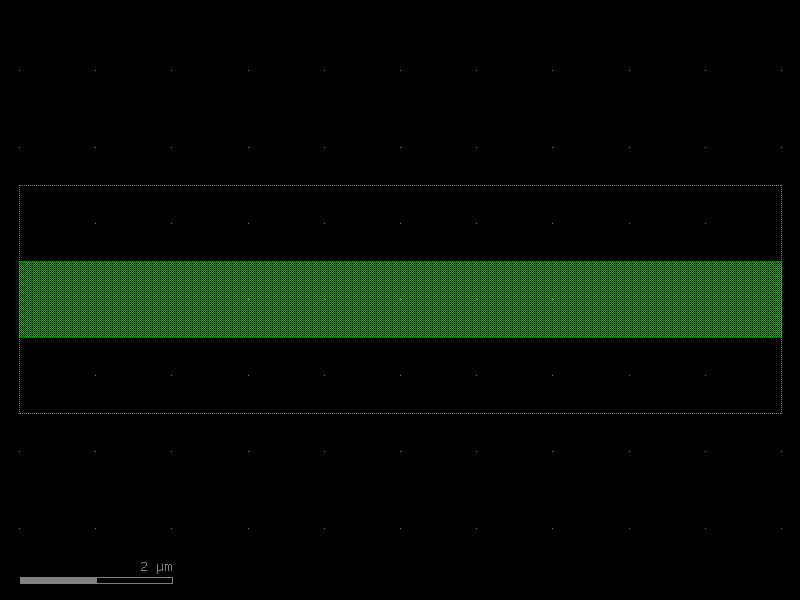

In [3]:
@kf.cell
def straight(width: float = 1.0, length: float = 10.0) -> kf.KCell:
    """Straight waveguide with WG core and WGEX exclusion zone.

    Args:
        width: waveguide width in µm
        length: waveguide length in µm
    """
    c = kf.KCell()
    ex = width + 2.0  # 1 µm exclusion on each side

    # Core geometry (µm coordinates via DBox)
    c.shapes(kf.kcl.find_layer(L.WG)).insert(
        kf.kdb.DBox(0, -width / 2, length, width / 2)
    )
    # Exclusion zone
    c.shapes(kf.kcl.find_layer(L.WGEX)).insert(kf.kdb.DBox(0, -ex / 2, length, ex / 2))

    # Ports — DCplxTrans(mag, angle_deg, mirror, x_um, y_um)
    wl = kf.kcl.find_layer(L.WG)
    wd = kf.kcl.to_dbu(width)
    c.add_port(
        port=kf.Port(
            name="o1",
            width=wd,
            dcplx_trans=kf.kdb.DCplxTrans(1, 180, False, 0, 0),
            layer=wl,
            kcl=kf.kcl,
        )
    )
    c.add_port(
        port=kf.Port(
            name="o2",
            width=wd,
            dcplx_trans=kf.kdb.DCplxTrans(1, 0, False, length, 0),
            layer=wl,
            kcl=kf.kcl,
        )
    )
    return c


wg = straight(width=1.0, length=10.0)
wg.plot()

## 3. Use built-in factory cells

kfactory ships with ready-made factory functions for common photonic primitives.
`bend_euler_factory` creates an Euler (clothoid) bend factory bound to a specific
`KCLayout`. Width and radius are in **µm**.

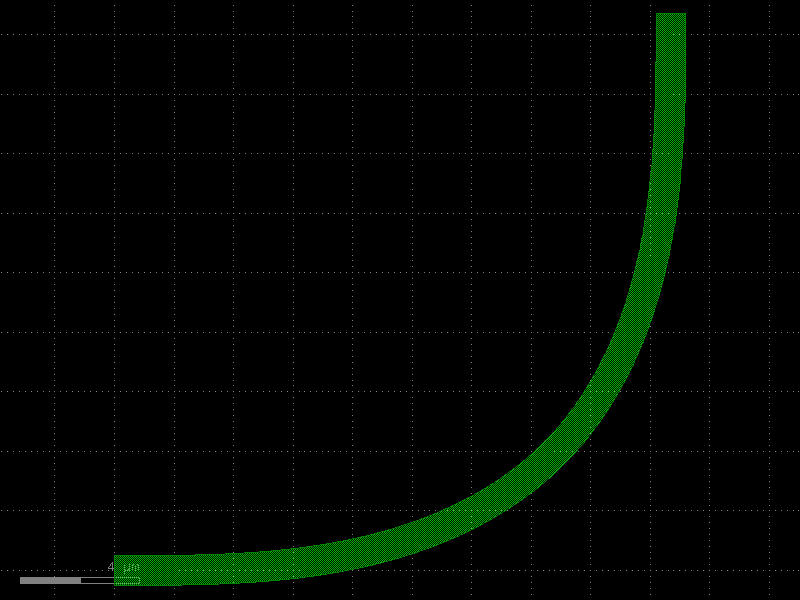

In [4]:
bend_euler = kf.factories.euler.bend_euler_factory(kcl=kf.kcl)

bend = bend_euler(width=1.0, radius=10.0, layer=L.WG)
bend.plot()

## 4. Assemble a circuit

Place instances with the `<<` operator and connect them port-to-port with
`instance.connect(own_port, other_instance_or_cell, other_port)`.

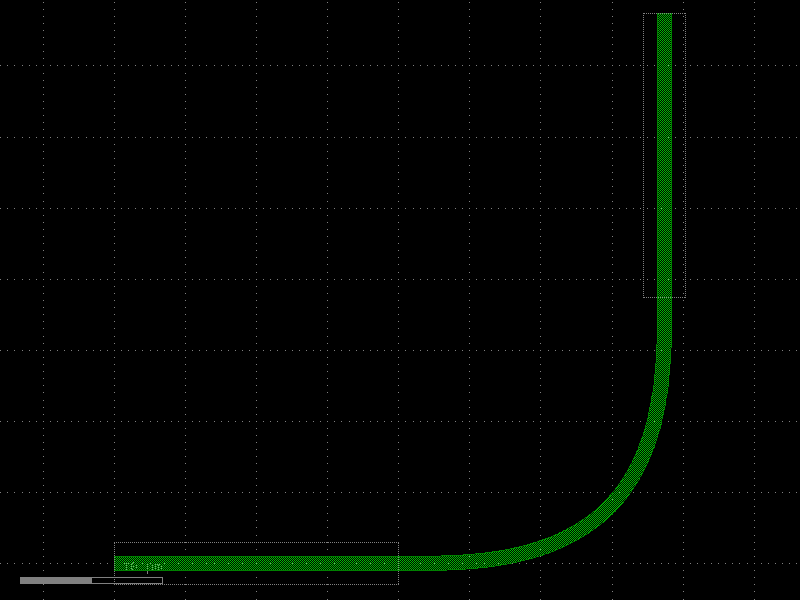

In [5]:
@kf.cell
def l_shaped_arm(
    wg_width: float = 1.0, bend_radius: float = 10.0, arm_length: float = 20.0
) -> kf.KCell:
    """Simple L-shaped arm: straight → 90° Euler bend → straight."""
    c = kf.KCell()

    _wg = straight(width=wg_width, length=arm_length)
    _bend = bend_euler(width=wg_width, radius=bend_radius, layer=L.WG)

    # Place instances
    i_wg1 = c << _wg
    i_bend = c << _bend
    i_wg2 = c << _wg

    # Connect in a chain
    i_bend.connect("o1", i_wg1, "o2")
    i_wg2.connect("o1", i_bend, "o2")

    # Expose the outer ports on the parent cell
    c.add_port(port=i_wg1.ports["o1"])
    c.add_port(port=i_wg2.ports["o2"])
    c.auto_rename_ports()
    return c


arm = l_shaped_arm()
arm.plot()

## 5. Inspect the result

Every cell carries metadata you can inspect:

In [6]:
print("Cell name    :", arm.name)
print("Bounding box :", arm.dbbox(), "µm")
print()
print("Ports:")
for p in arm.ports:
    print(
        f"  {p.name:4s}  layer={p.layer}"
        f"  width={kf.kcl.to_um(p.width):.3f} µm"
        f"  @ ({kf.kcl.to_um(p.x):.1f}, {kf.kcl.to_um(p.y):.1f}) µm"
        f"  angle={p.trans.angle * 90}°"
    )

Cell name    : l_shaped_arm_WW1_BR10_AL20
Bounding box : (0,-1.5;40.201,38.701) µm

Ports:
  o1    layer=WG  width=1.000 µm  @ (0.0, 0.0) µm  angle=180°
  o2    layer=WG  width=1.000 µm  @ (38.7, 38.7) µm  angle=90°


## 6. Stream to KLayout (optional)

If [klive](klive_setup.md) is installed and KLayout is open, a single call pushes the
GDS to the viewer:

```python
kf.show(arm)
```

## Next steps

| Topic | Where |
|-------|-------|
| Cells in depth | [Core Concepts: KCell](../concepts/kcell.py) |
| Layers & layer stacks | [Core Concepts: Layers](../concepts/layers.py) |
| Port system | [Core Concepts: Ports](../concepts/ports.py) |
| DBU vs µm coordinates | [Core Concepts: DBU vs µm](../concepts/dbu_vs_um.py) |
| Optical routing | [Routing: Optical](../routing/optical.py) |
| Enclosures / cladding | [Enclosures: Layer Enclosure](../enclosures/layer_enclosure.py) |